In [1]:
# 04 - SVM Classifier (RBF and Linear Kernels) on Diabetes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score)

In [3]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']

data = pd.read_csv('datasets/diabetes.csv', header=None, names=col_names)
print("Shape:", data.shape)
print(data.head())

Shape: (768, 9)
   pregnant  glucose  bp  skin  insulin   bmi  pedigree  age  label
0         6      148  72    35        0  33.6     0.627   50      1
1         1       85  66    29        0  26.6     0.351   31      0
2         8      183  64     0        0  23.3     0.672   32      1
3         1       89  66    23       94  28.1     0.167   21      0
4         0      137  40    35      168  43.1     2.288   33      1


In [4]:
print("Null values:")
print(data.isnull().sum())

Null values:
pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64


In [5]:
feature_cols = ['pregnant', 'insulin', 'bmi',
               'age', 'glucose', 'bp', 'pedigree']
X = data[feature_cols]
y = data['label']
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (768, 7) y shape: (768,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=5
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (537, 7) Test: (231, 7)


In [7]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)
print("Standardised.")

Standardised.


In [8]:
# Train SVM with RBF kernel

In [9]:
model_rbf = SVC(kernel='rbf', random_state=0)
model_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = model_rbf.predict(X_test_scaled)
print("First 20 predictions (rbf):", y_pred_rbf[:20])

First 20 predictions (rbf): [0 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0]


In [10]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
print("SVC [kernel = rbf]")
print("Confusion Matrix:")
print(cm_rbf)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print("Accuracy  :", acc_rbf)
print(classification_report(y_test, y_pred_rbf))

SVC [kernel = rbf]
Confusion Matrix:
[[135  25]
 [ 22  49]]
Accuracy  : 0.7965367965367965
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       160
           1       0.66      0.69      0.68        71

    accuracy                           0.80       231
   macro avg       0.76      0.77      0.76       231
weighted avg       0.80      0.80      0.80       231



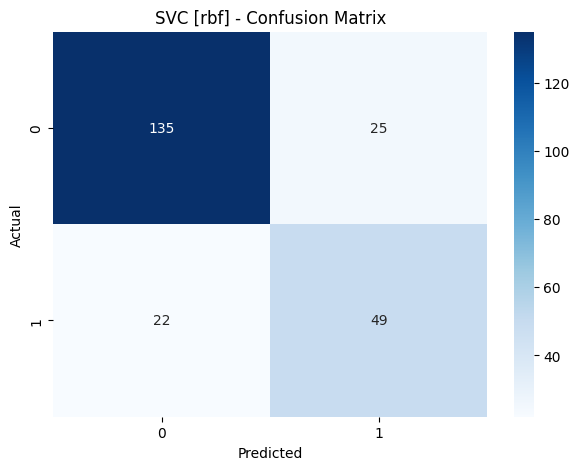

In [11]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVC [rbf] - Confusion Matrix')
plt.show()

In [12]:
# Train SVM with Linear kernel

In [13]:
model_lin = SVC(kernel='linear', random_state=0)
model_lin.fit(X_train_scaled, y_train)
y_pred_lin = model_lin.predict(X_test_scaled)
print("First 20 predictions (linear):", y_pred_lin[:20])

First 20 predictions (linear): [0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 1 0 0]


In [14]:
cm_lin = confusion_matrix(y_test, y_pred_lin)
print("SVC [kernel = linear]")
print("Confusion Matrix:")
print(cm_lin)
acc_lin = accuracy_score(y_test, y_pred_lin)
print("Accuracy  :", acc_lin)
print(classification_report(y_test, y_pred_lin))

SVC [kernel = linear]
Confusion Matrix:
[[136  24]
 [ 23  48]]
Accuracy  : 0.7965367965367965


              precision    recall  f1-score   support

           0       0.86      0.85      0.85       160
           1       0.67      0.68      0.67        71

    accuracy                           0.80       231
   macro avg       0.76      0.76      0.76       231
weighted avg       0.80      0.80      0.80       231



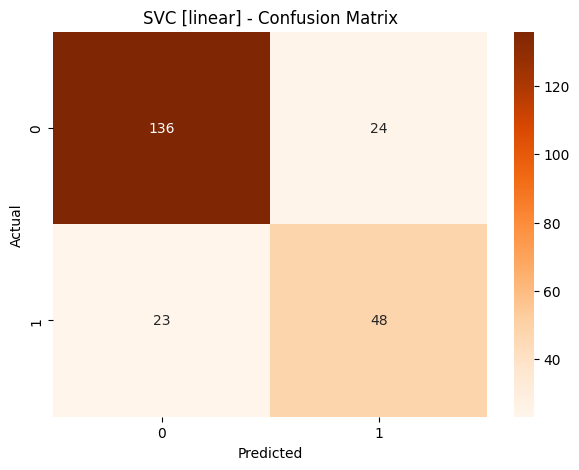

In [15]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lin, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVC [linear] - Confusion Matrix')
plt.show()

In [16]:
# Kernel Comparison

   Kernel  Accuracy
0     RBF  0.796537
1  Linear  0.796537


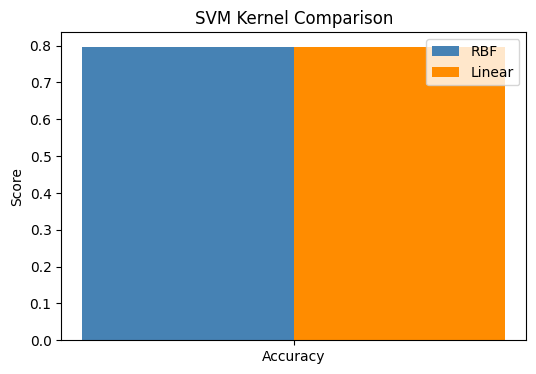

In [17]:
comparison = pd.DataFrame({
    'Kernel'   : ['RBF', 'Linear'],
    'Accuracy' : [acc_rbf,  acc_lin],
})
print(comparison)

metrics_list = ['Accuracy']
x = np.arange(len(metrics_list))
w = 0.35
plt.figure(figsize=(6, 4))
plt.bar(x - w/2, [acc_rbf],  w, label='RBF',   color='steelblue')
plt.bar(x + w/2, [acc_lin], w, label='Linear', color='darkorange')
plt.xticks(x, metrics_list)
plt.ylabel('Score')
plt.title('SVM Kernel Comparison')
plt.legend()
plt.show()